# Solar Power Systems - Exploratory Data Analysis (EDA)

**Objective:** Understand the data from Site 1 (solar generation, irradiance, temperature, load) to prepare for anomaly detection.

**Data:**
- `gen_337` - Solar production (kW)
- `Irradiance_339` - Solar irradiance (W/m²)
- `Temp-Ambient_340` - Ambient temperature (°C)
- `load_338` - Power consumption/load (kW)

**Date range:** 2025-06-01 to 2025-12-01 (6 months)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Load Raw Data

In [3]:
DATA_DIR = 'datasets/site_1/'

gen = pd.read_csv(DATA_DIR + 'gen_337_20250601_20251201.csv', parse_dates=['date/time'])
irr = pd.read_csv(DATA_DIR + 'Irradiance_339_20250601_20251201.csv', parse_dates=['date/time'])
temp = pd.read_csv(DATA_DIR + 'Temp-Ambient_340_20250601_20251201.csv', parse_dates=['date/time'])
load = pd.read_csv(DATA_DIR + 'load_338_20250601_20251201.csv', parse_dates=['date/time'])

# Rename columns for clarity
gen.columns = ['datetime', 'generation_kw']
irr.columns = ['datetime', 'irradiance_wm2']
temp.columns = ['datetime', 'temperature_c']
load.columns = ['datetime', 'load_kw']

print(f'Generation : {gen.shape[0]:,} rows, {gen.datetime.min()} to {gen.datetime.max()}')
print(f'Irradiance : {irr.shape[0]:,} rows, {irr.datetime.min()} to {irr.datetime.max()}')
print(f'Temperature: {temp.shape[0]:,} rows, {temp.datetime.min()} to {temp.datetime.max()}')
print(f'Load       : {load.shape[0]:,} rows, {load.datetime.min()} to {load.datetime.max()}')

Generation : 26,226 rows, 2025-06-01 01:03:15 to 2025-12-01 23:59:16
Irradiance : 26,177 rows, 2025-06-01 01:03:15 to 2025-12-01 23:59:16
Temperature: 26,195 rows, 2025-06-01 01:03:15 to 2025-12-01 23:59:16
Load       : 17,367 rows, 2025-06-01 00:00:00 to 2025-12-01 23:45:00


## 2. Null / Missing Value Analysis

In [4]:
print('=== Null counts per dataset ===')
for name, df in [('Generation', gen), ('Irradiance', irr), ('Temperature', temp), ('Load', load)]:
    nulls = df.isnull().sum()
    pct = (df.isnull().sum() / len(df) * 100).round(2)
    print(f'\n{name}:')
    for col in df.columns:
        print(f'  {col}: {nulls[col]} nulls ({pct[col]}%)')

=== Null counts per dataset ===

Generation:
  datetime: 0 nulls (0.0%)
  generation_kw: 0 nulls (0.0%)

Irradiance:
  datetime: 0 nulls (0.0%)
  irradiance_wm2: 0 nulls (0.0%)

Temperature:
  datetime: 0 nulls (0.0%)
  temperature_c: 0 nulls (0.0%)

Load:
  datetime: 0 nulls (0.0%)
  load_kw: 0 nulls (0.0%)


In [5]:
# Check for time gaps - gen, irr, temp are ~1-min; load is 15-min
print('=== Time interval analysis ===')
for name, df in [('Generation', gen), ('Irradiance', irr), ('Temperature', temp), ('Load', load)]:
    diffs = df['datetime'].diff().dropna()
    print(f'\n{name}:')
    print(f'  Median interval: {diffs.median()}')
    print(f'  Min interval   : {diffs.min()}')
    print(f'  Max interval   : {diffs.max()}')
    # Show gaps > 2x median
    gaps = diffs[diffs > 2 * diffs.median()]
    print(f'  Gaps > 2x median: {len(gaps)}')

=== Time interval analysis ===

Generation:
  Median interval: 0 days 00:01:00
  Min interval   : 0 days 00:01:00
  Max interval   : 5 days 20:02:40
  Gaps > 2x median: 3254

Irradiance:
  Median interval: 0 days 00:01:00
  Min interval   : 0 days 00:01:00
  Max interval   : 5 days 20:02:40
  Gaps > 2x median: 3282

Temperature:
  Median interval: 0 days 00:01:00
  Min interval   : 0 days 00:01:00
  Max interval   : 5 days 20:02:39
  Gaps > 2x median: 3250

Load:
  Median interval: 0 days 00:15:00
  Min interval   : 0 days 00:01:06
  Max interval   : 2 days 18:45:00
  Gaps > 2x median: 5


## 3. Resample to Uniform 15-min Intervals & Merge

In [6]:
# Resample gen, irr, temp from ~1-min to 15-min (mean aggregation)
# Load is already 15-min
gen_15 = gen.set_index('datetime').resample('15min').mean()
irr_15 = irr.set_index('datetime').resample('15min').mean()
temp_15 = temp.set_index('datetime').resample('15min').mean()
load_15 = load.set_index('datetime').resample('15min').mean()

# Merge all into one dataframe
df = gen_15.join([irr_15, temp_15, load_15], how='outer')
df = df.sort_index()

print(f'Merged dataframe: {df.shape}')
print(f'Date range: {df.index.min()} to {df.index.max()}')
df.head(10)

Merged dataframe: (17664, 4)
Date range: 2025-06-01 00:00:00 to 2025-12-01 23:45:00


,generation_kw,irradiance_wm2,temperature_c,load_kw
datetime,,,,
2025-06-01 00:00:00,NaN,NaN,NaN,279.0
2025-06-01 00:15:00,NaN,NaN,NaN,261.0
2025-06-01 00:30:00,NaN,NaN,NaN,274.0
2025-06-01 00:45:00,NaN,NaN,NaN,263.0
2025-06-01 01:00:00,0.0,0.0,24.8,274.0
2025-06-01 01:15:00,NaN,NaN,NaN,273.0
2025-06-01 01:30:00,NaN,NaN,NaN,284.0
2025-06-01 01:45:00,NaN,NaN,NaN,261.0
2025-06-01 02:00:00,NaN,NaN,NaN,270.0


In [7]:
# Null analysis after merge
print('=== Nulls after merge ===')
null_counts = df.isnull().sum()
null_pct = (df.isnull().sum() / len(df) * 100).round(2)
null_summary = pd.DataFrame({'nulls': null_counts, 'pct': null_pct})
print(null_summary)
print(f'\nTotal rows: {len(df)}')

=== Nulls after merge ===
                nulls    pct
generation_kw   13250  75.01
irradiance_wm2  13257  75.05
temperature_c   13260  75.07
load_kw           301   1.70

Total rows: 17664


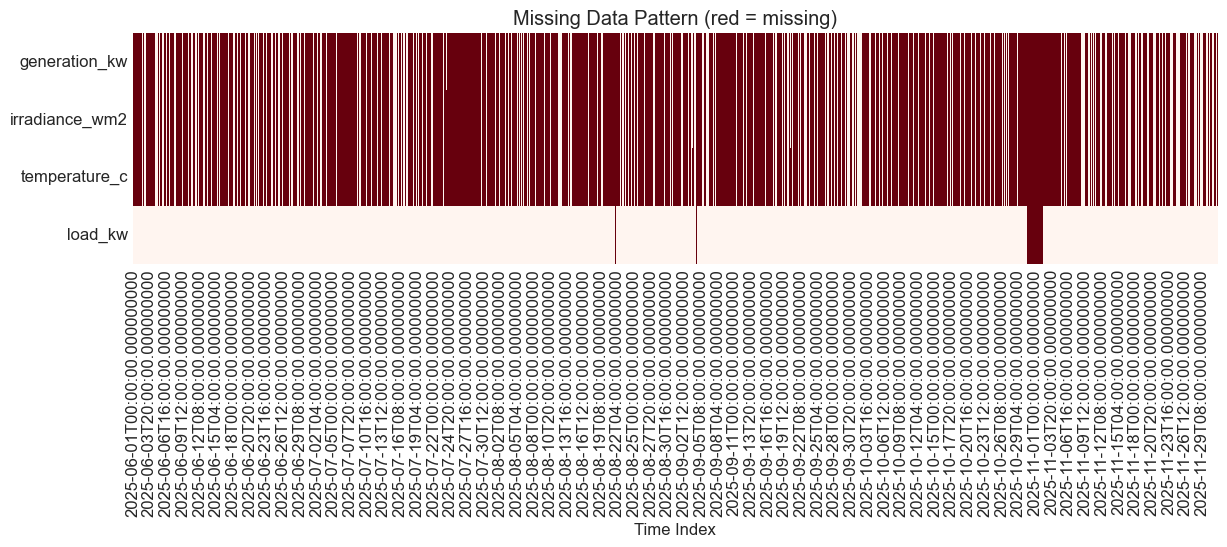

In [8]:
# Visualize missing data pattern
fig, ax = plt.subplots(figsize=(14, 3))
sns.heatmap(df.isnull().T, cbar=False, yticklabels=True, cmap='Reds', ax=ax)
ax.set_title('Missing Data Pattern (red = missing)')
ax.set_xlabel('Time Index')
plt.tight_layout()
plt.show()

## 4. Handle Missing Values

In [9]:
# Strategy:
# 1. Forward fill small gaps (up to 4 intervals = 1 hour)
# 2. Then interpolate remaining small gaps linearly
# 3. Leave large gaps as NaN (will drop later or handle per-model)

df_clean = df.copy()
df_clean = df_clean.ffill(limit=4)
df_clean = df_clean.interpolate(method='time', limit=4)

print('=== Nulls after cleaning ===')
null_after = df_clean.isnull().sum()
null_pct_after = (df_clean.isnull().sum() / len(df_clean) * 100).round(2)
print(pd.DataFrame({'before': df.isnull().sum(), 'after': null_after, 'pct_remaining': null_pct_after}))

# Drop remaining rows with NaN
df_clean = df_clean.dropna()
print(f'\nFinal clean rows: {len(df_clean)} (dropped {len(df) - len(df_clean)} rows)')

=== Nulls after cleaning ===
                before  after  pct_remaining
generation_kw    13250   2601          14.72
irradiance_wm2   13257   2611          14.78
temperature_c    13260   2612          14.79
load_kw            301    258           1.46

Final clean rows: 15013 (dropped 2651 rows)


## 5. Basic Statistics

In [10]:
df_clean.describe().round(2)

,generation_kw,irradiance_wm2,temperature_c,load_kw
count,15013.00,15013.00,15013.00,15013.00
mean,96.53,157.76,28.73,737.19
std,150.86,243.96,3.01,417.73
min,0.00,0.00,0.00,0.00
25%,0.00,0.00,26.96,408.00
50%,2.00,0.00,28.54,755.00
75%,159.00,259.62,30.60,1090.00
max,638.00,1073.00,37.05,1810.00


## 6. Time Series Visualization

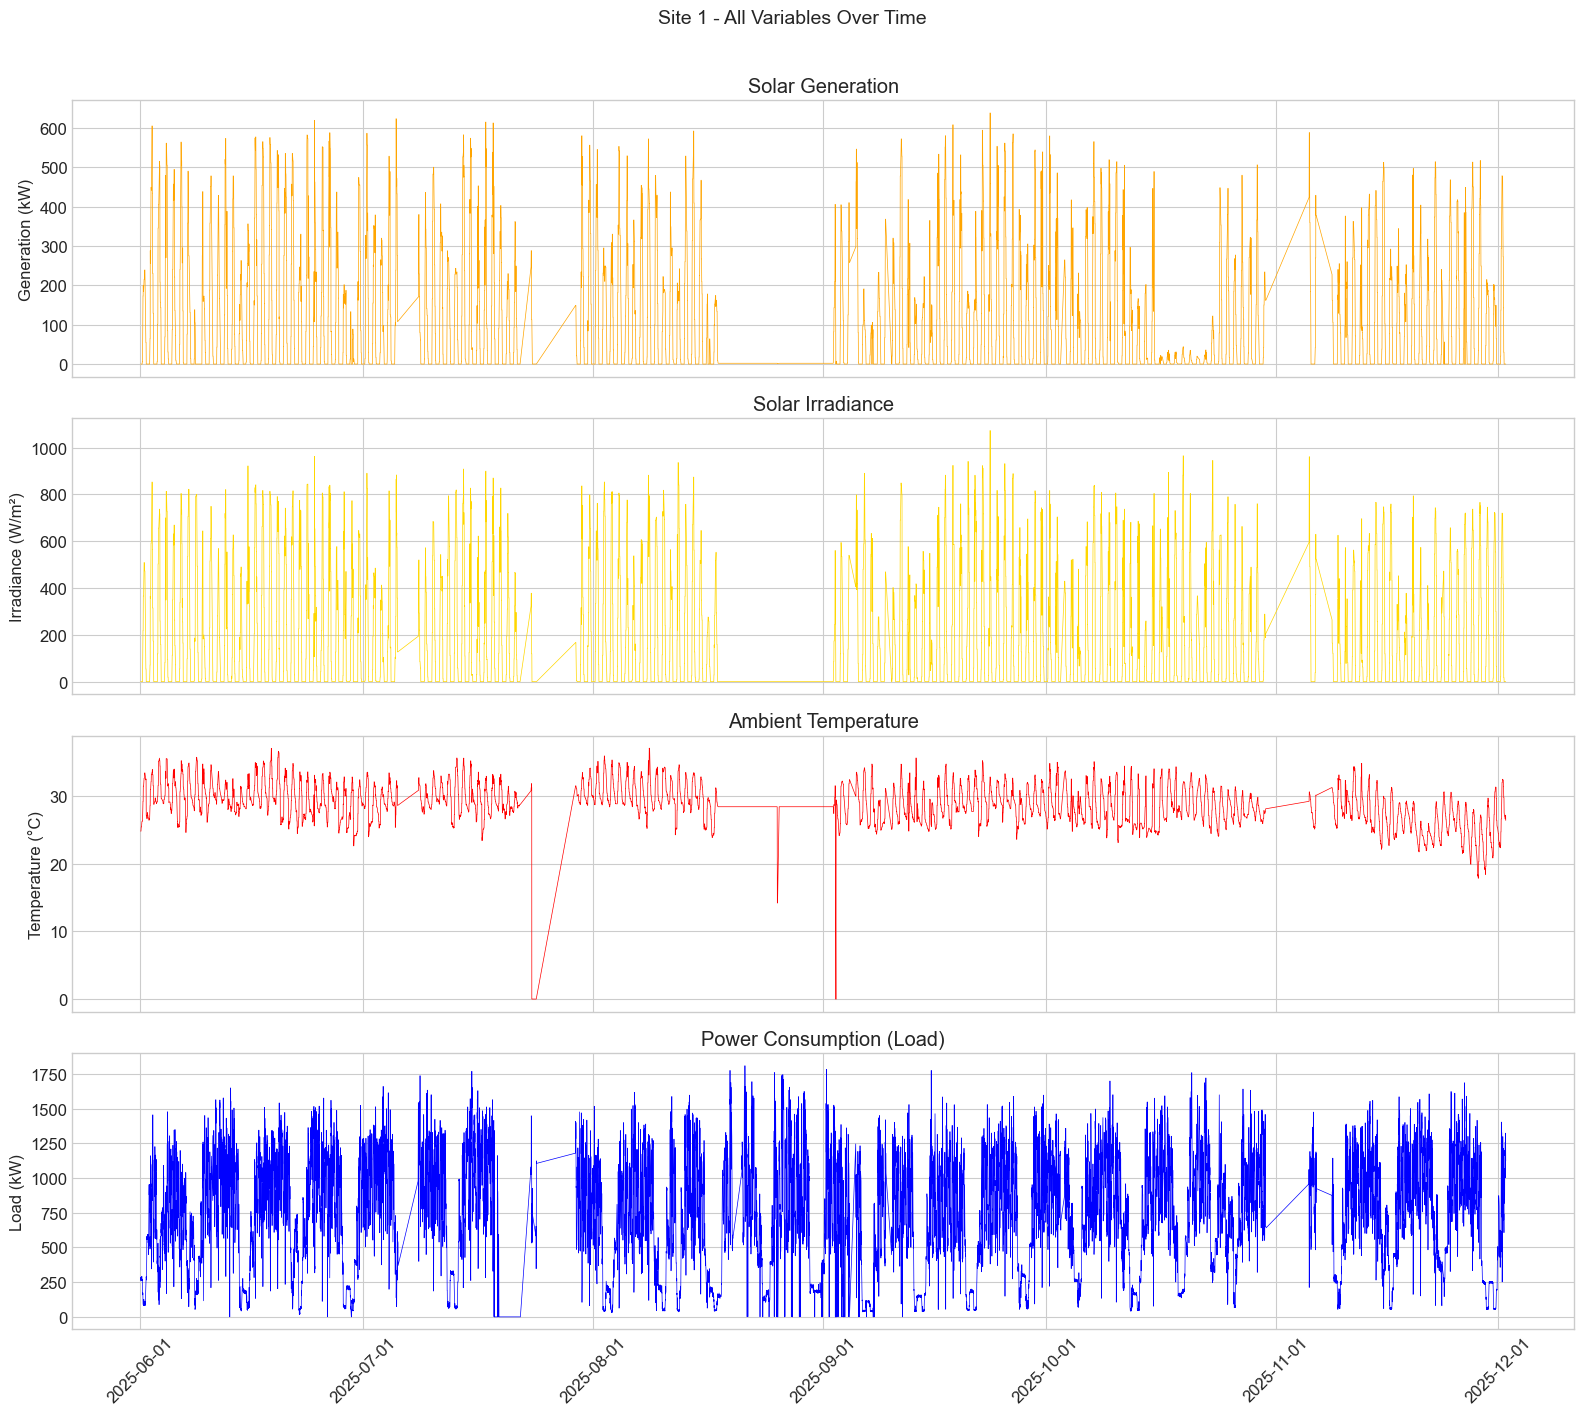

In [11]:
fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)

axes[0].plot(df_clean.index, df_clean['generation_kw'], color='orange', linewidth=0.5)
axes[0].set_ylabel('Generation (kW)')
axes[0].set_title('Solar Generation')

axes[1].plot(df_clean.index, df_clean['irradiance_wm2'], color='gold', linewidth=0.5)
axes[1].set_ylabel('Irradiance (W/m\u00b2)')
axes[1].set_title('Solar Irradiance')

axes[2].plot(df_clean.index, df_clean['temperature_c'], color='red', linewidth=0.5)
axes[2].set_ylabel('Temperature (\u00b0C)')
axes[2].set_title('Ambient Temperature')

axes[3].plot(df_clean.index, df_clean['load_kw'], color='blue', linewidth=0.5)
axes[3].set_ylabel('Load (kW)')
axes[3].set_title('Power Consumption (Load)')

axes[3].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)
plt.suptitle('Site 1 - All Variables Over Time', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

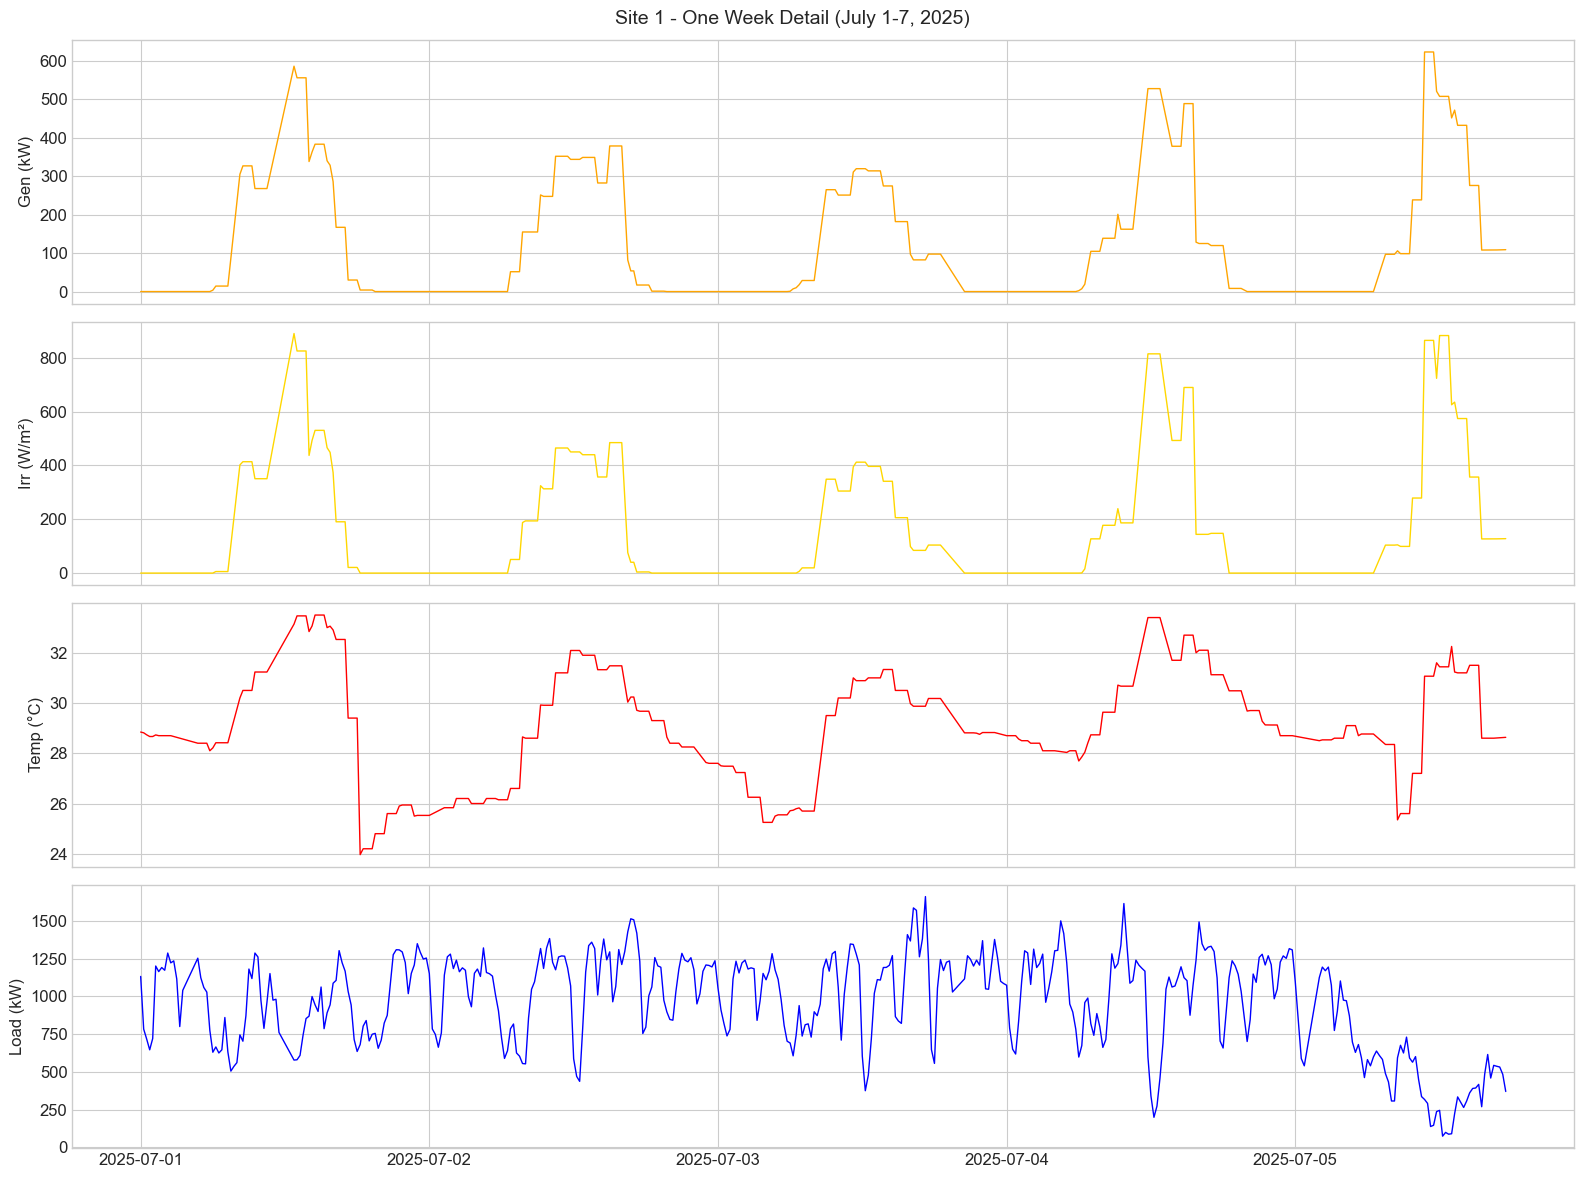

In [12]:
# Zoom in: one week of data
week = df_clean['2025-07-01':'2025-07-07']

fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)

axes[0].plot(week.index, week['generation_kw'], color='orange', linewidth=1)
axes[0].set_ylabel('Gen (kW)')

axes[1].plot(week.index, week['irradiance_wm2'], color='gold', linewidth=1)
axes[1].set_ylabel('Irr (W/m\u00b2)')

axes[2].plot(week.index, week['temperature_c'], color='red', linewidth=1)
axes[2].set_ylabel('Temp (\u00b0C)')

axes[3].plot(week.index, week['load_kw'], color='blue', linewidth=1)
axes[3].set_ylabel('Load (kW)')

plt.suptitle('Site 1 - One Week Detail (July 1-7, 2025)', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Distribution Analysis

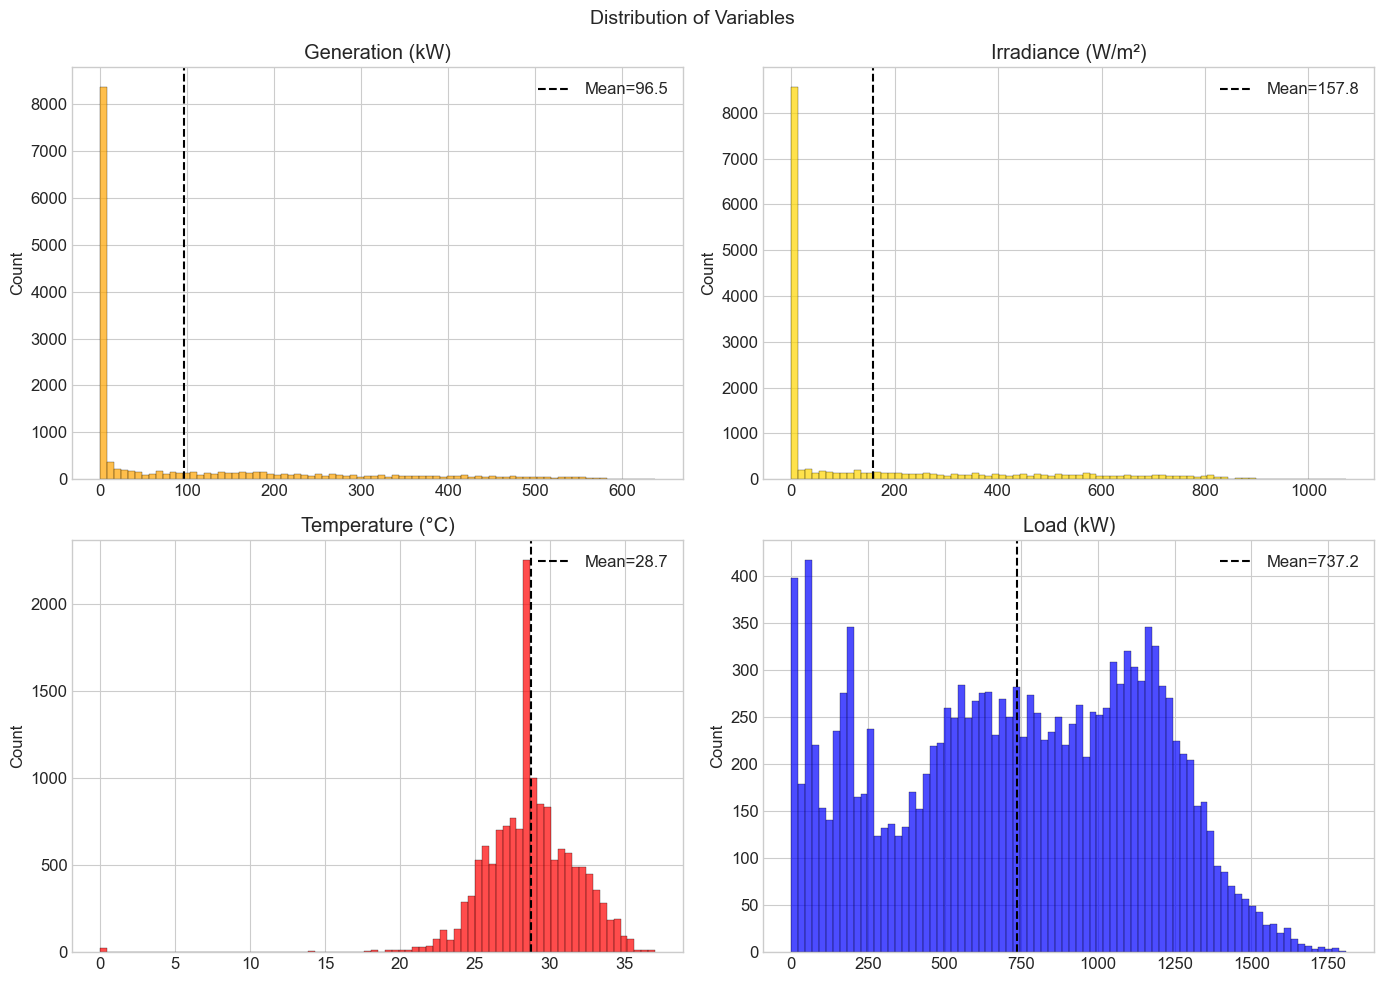

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
cols = ['generation_kw', 'irradiance_wm2', 'temperature_c', 'load_kw']
colors = ['orange', 'gold', 'red', 'blue']
titles = ['Generation (kW)', 'Irradiance (W/m\u00b2)', 'Temperature (\u00b0C)', 'Load (kW)']

for ax, col, color, title in zip(axes.flat, cols, colors, titles):
    ax.hist(df_clean[col], bins=80, color=color, alpha=0.7, edgecolor='black', linewidth=0.3)
    ax.set_title(title)
    ax.set_ylabel('Count')
    ax.axvline(df_clean[col].mean(), color='black', linestyle='--', label=f'Mean={df_clean[col].mean():.1f}')
    ax.legend()

plt.suptitle('Distribution of Variables', fontsize=14)
plt.tight_layout()
plt.show()

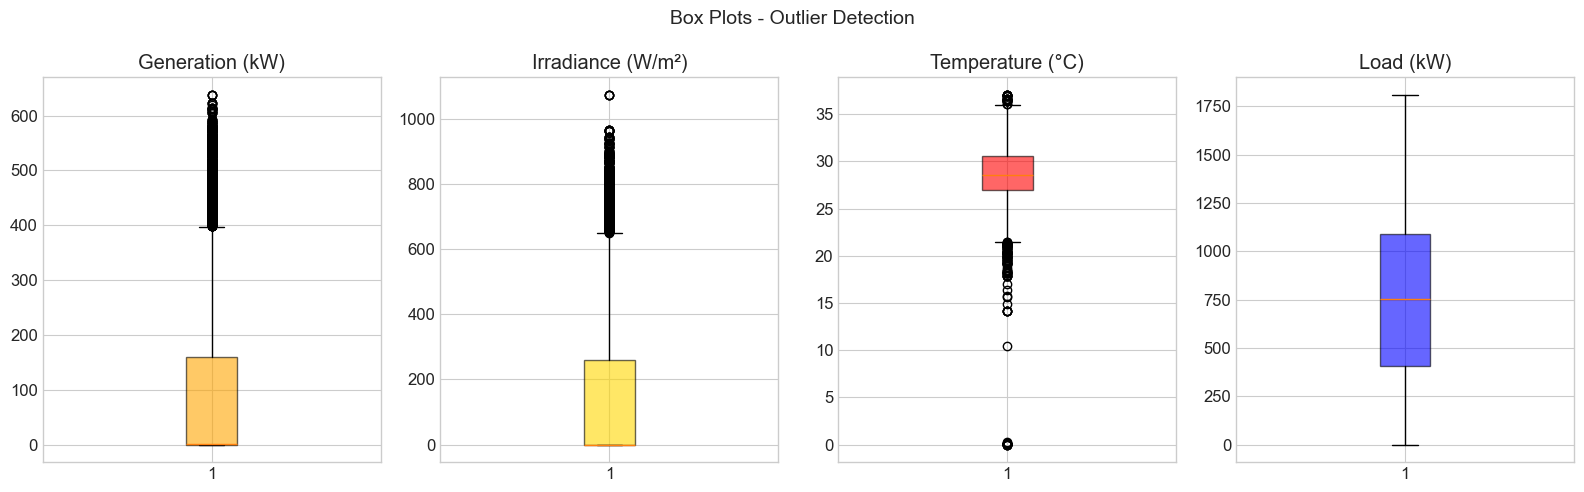

In [14]:
# Box plots
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, col, color, title in zip(axes, cols, colors, titles):
    ax.boxplot(df_clean[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6))
    ax.set_title(title)
plt.suptitle('Box Plots - Outlier Detection', fontsize=14)
plt.tight_layout()
plt.show()

## 8. Correlation Analysis

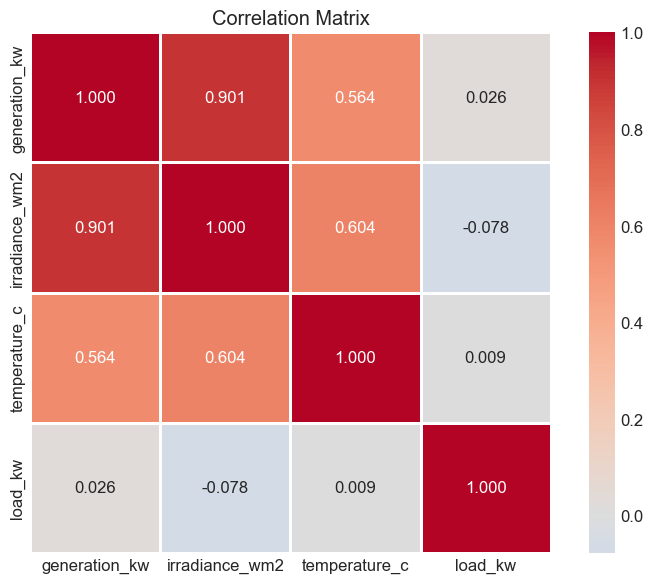

Key correlations with generation_kw:
generation_kw     1.000000
irradiance_wm2    0.900979
temperature_c     0.564246
load_kw           0.025960
Name: generation_kw, dtype: float64


In [15]:
corr = df_clean.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.3f',
            square=True, linewidths=1, ax=ax)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

print('Key correlations with generation_kw:')
print(corr['generation_kw'].sort_values(ascending=False))

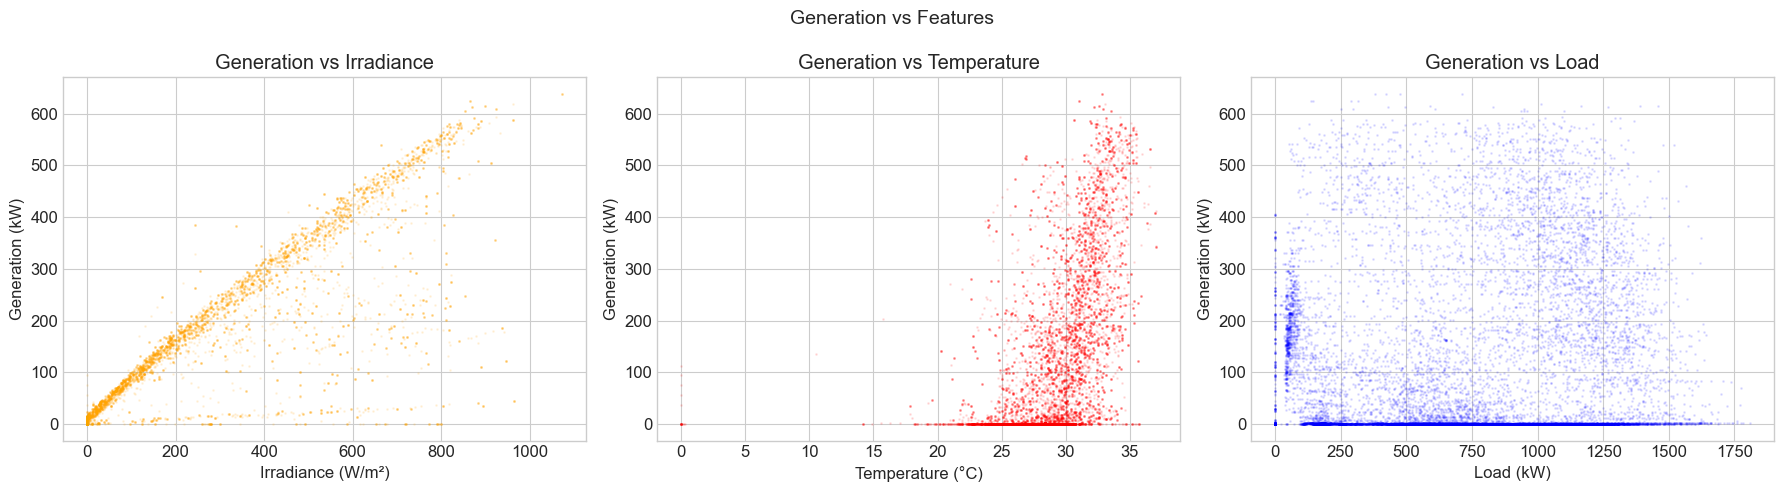

In [16]:
# Scatter plots: generation vs each feature
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(df_clean['irradiance_wm2'], df_clean['generation_kw'],
                alpha=0.1, s=1, color='orange')
axes[0].set_xlabel('Irradiance (W/m\u00b2)')
axes[0].set_ylabel('Generation (kW)')
axes[0].set_title('Generation vs Irradiance')

axes[1].scatter(df_clean['temperature_c'], df_clean['generation_kw'],
                alpha=0.1, s=1, color='red')
axes[1].set_xlabel('Temperature (\u00b0C)')
axes[1].set_ylabel('Generation (kW)')
axes[1].set_title('Generation vs Temperature')

axes[2].scatter(df_clean['load_kw'], df_clean['generation_kw'],
                alpha=0.1, s=1, color='blue')
axes[2].set_xlabel('Load (kW)')
axes[2].set_ylabel('Generation (kW)')
axes[2].set_title('Generation vs Load')

plt.suptitle('Generation vs Features', fontsize=14)
plt.tight_layout()
plt.show()

## 9. Daily & Hourly Patterns

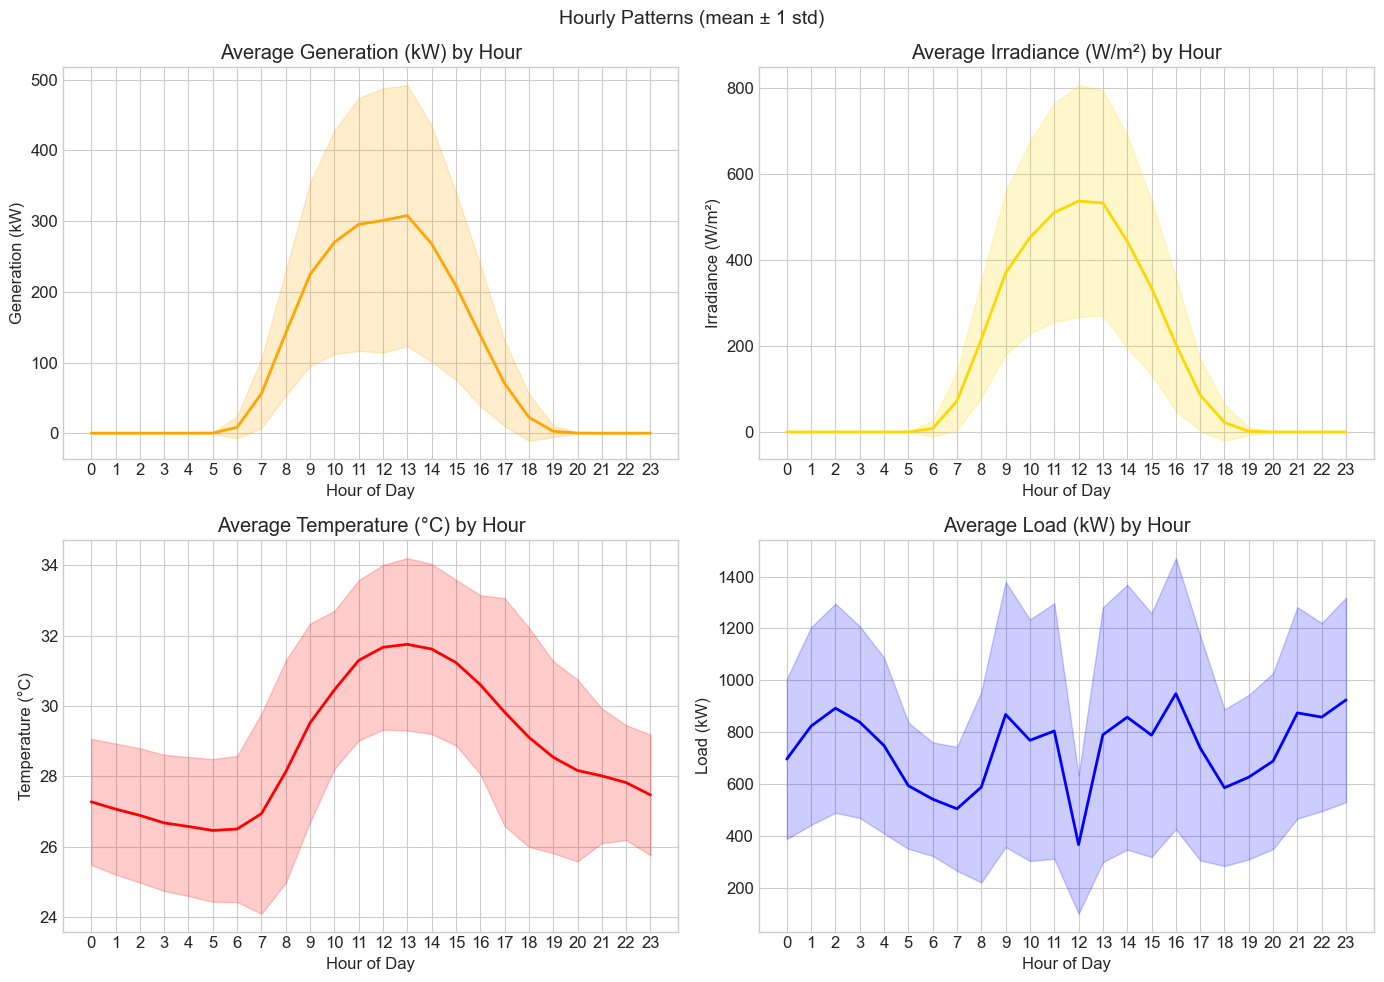

In [17]:
df_clean['hour'] = df_clean.index.hour
df_clean['month'] = df_clean.index.month
df_clean['dayofweek'] = df_clean.index.dayofweek

# Hourly average pattern
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col, color, title in zip(axes.flat, cols, colors, titles):
    hourly = df_clean.groupby('hour')[col].agg(['mean', 'std'])
    ax.plot(hourly.index, hourly['mean'], color=color, linewidth=2)
    ax.fill_between(hourly.index, hourly['mean'] - hourly['std'],
                    hourly['mean'] + hourly['std'], alpha=0.2, color=color)
    ax.set_xlabel('Hour of Day')
    ax.set_ylabel(title)
    ax.set_title(f'Average {title} by Hour')
    ax.set_xticks(range(0, 24))

plt.suptitle('Hourly Patterns (mean \u00b1 1 std)', fontsize=14)
plt.tight_layout()
plt.show()

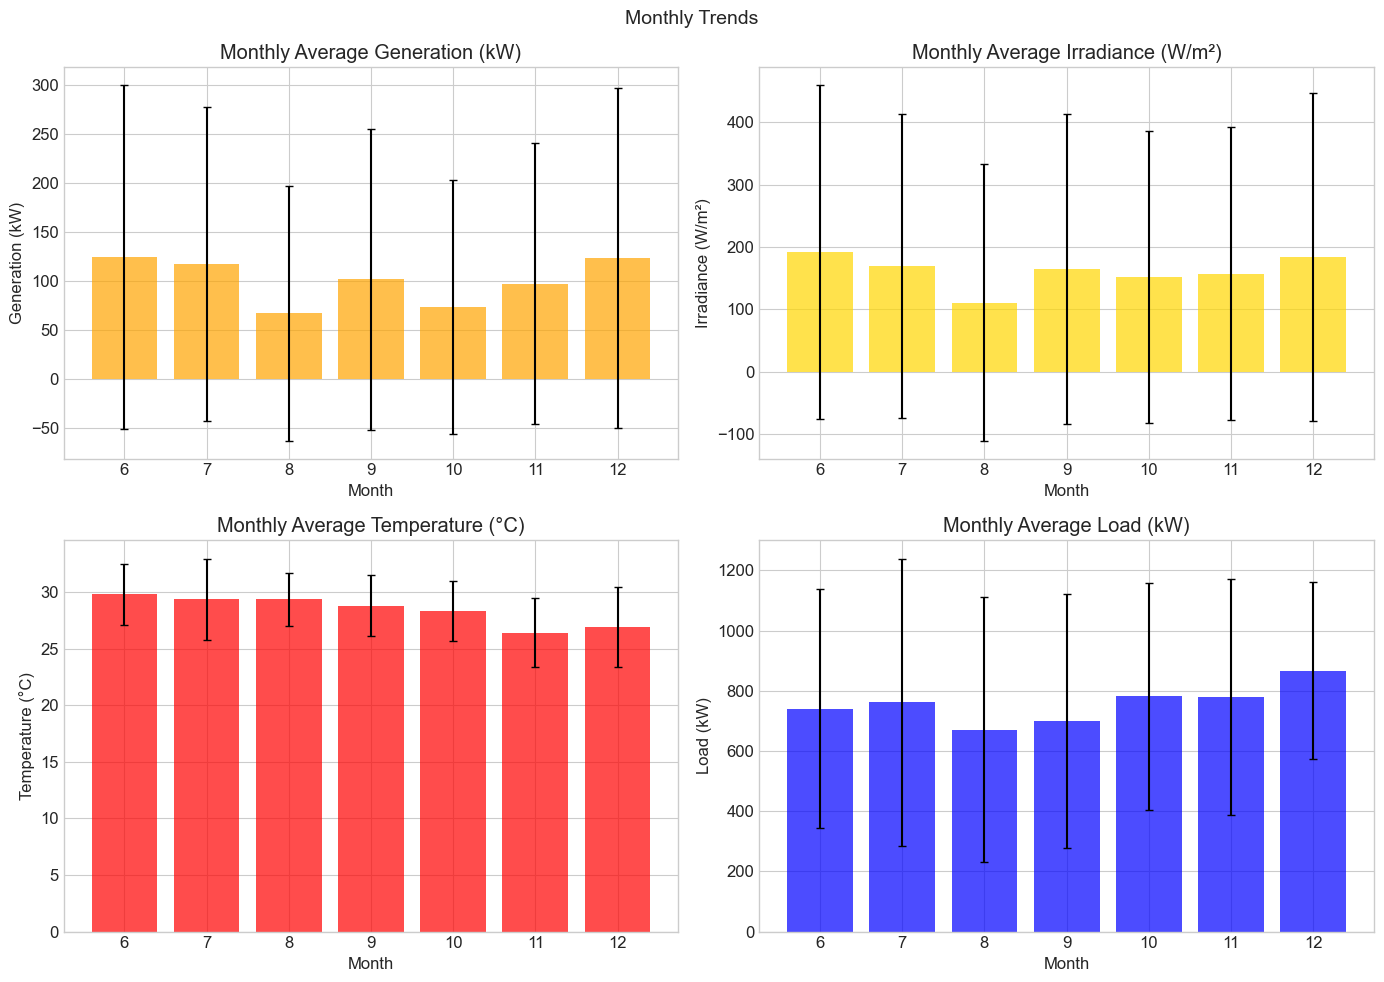

In [18]:
# Monthly trends
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col, color, title in zip(axes.flat, cols, colors, titles):
    monthly = df_clean.groupby('month')[col].agg(['mean', 'std'])
    ax.bar(monthly.index, monthly['mean'], color=color, alpha=0.7, yerr=monthly['std'], capsize=3)
    ax.set_xlabel('Month')
    ax.set_ylabel(title)
    ax.set_title(f'Monthly Average {title}')

plt.suptitle('Monthly Trends', fontsize=14)
plt.tight_layout()
plt.show()

## 10. Generation Efficiency Analysis

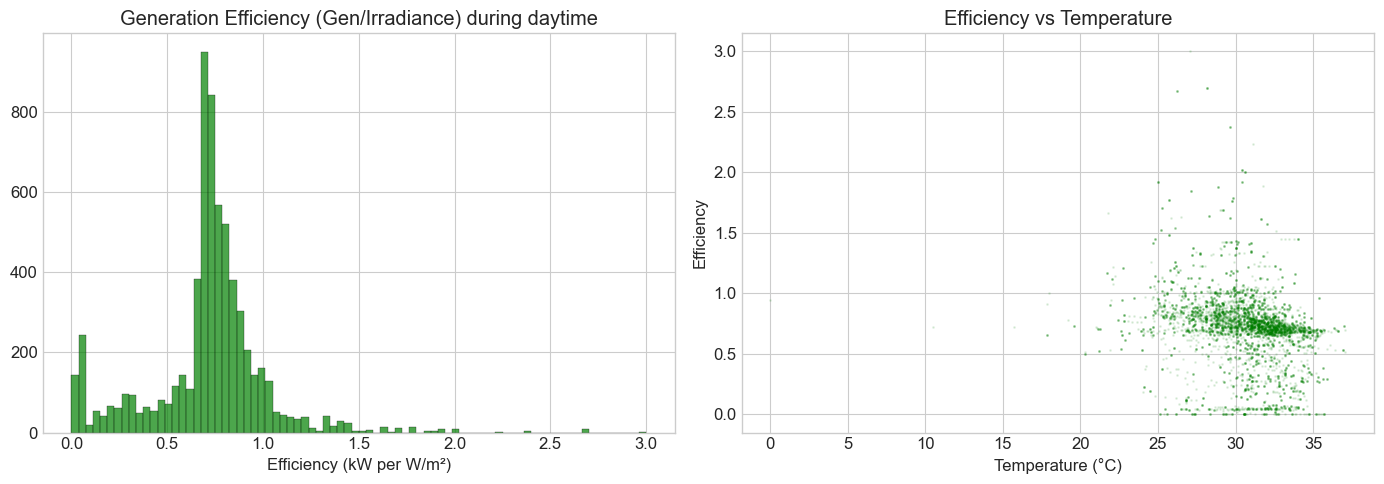

Daytime samples: 6519
Efficiency stats:
count    6519.000000
mean        0.713122
std         0.307992
min         0.000000
25%         0.656315
50%         0.729211
75%         0.837398
max         3.000000
Name: efficiency, dtype: float64


In [19]:
# When irradiance > 0, what is the generation efficiency?
daytime = df_clean[df_clean['irradiance_wm2'] > 10].copy()
daytime['efficiency'] = daytime['generation_kw'] / daytime['irradiance_wm2']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(daytime['efficiency'], bins=80, color='green', alpha=0.7, edgecolor='black', linewidth=0.3)
axes[0].set_title('Generation Efficiency (Gen/Irradiance) during daytime')
axes[0].set_xlabel('Efficiency (kW per W/m\u00b2)')

axes[1].scatter(daytime['temperature_c'], daytime['efficiency'], alpha=0.1, s=1, color='green')
axes[1].set_title('Efficiency vs Temperature')
axes[1].set_xlabel('Temperature (\u00b0C)')
axes[1].set_ylabel('Efficiency')

plt.tight_layout()
plt.show()

print(f'Daytime samples: {len(daytime)}')
print(f'Efficiency stats:\n{daytime["efficiency"].describe()}')

## 11. Anomaly Indicators (Visual Inspection)

High irradiance but low generation: 0 samples
Generation with no sunlight: 1655 samples


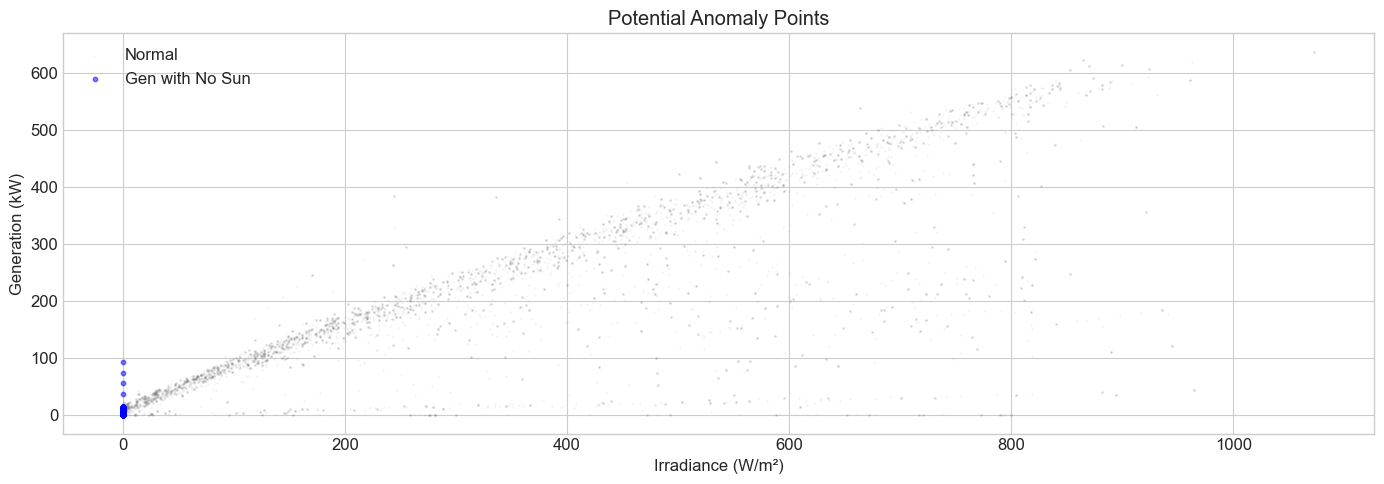

In [20]:
# Flag potential anomalies:
# 1. High irradiance but low/zero generation (possible equipment failure)
# 2. Generation when irradiance is zero (sensor/data error)

high_irr_low_gen = df_clean[
    (df_clean['irradiance_wm2'] > df_clean['irradiance_wm2'].quantile(0.75)) &
    (df_clean['generation_kw'] < df_clean['generation_kw'].quantile(0.1))
]

gen_no_sun = df_clean[
    (df_clean['irradiance_wm2'] <= 0) &
    (df_clean['generation_kw'] > 1)
]

print(f'High irradiance but low generation: {len(high_irr_low_gen)} samples')
print(f'Generation with no sunlight: {len(gen_no_sun)} samples')

fig, ax = plt.subplots(figsize=(14, 5))
ax.scatter(df_clean['irradiance_wm2'], df_clean['generation_kw'],
           alpha=0.05, s=1, color='gray', label='Normal')
if len(high_irr_low_gen) > 0:
    ax.scatter(high_irr_low_gen['irradiance_wm2'], high_irr_low_gen['generation_kw'],
               alpha=0.5, s=10, color='red', label='High Irr / Low Gen')
if len(gen_no_sun) > 0:
    ax.scatter(gen_no_sun['irradiance_wm2'], gen_no_sun['generation_kw'],
               alpha=0.5, s=10, color='blue', label='Gen with No Sun')
ax.set_xlabel('Irradiance (W/m\u00b2)')
ax.set_ylabel('Generation (kW)')
ax.set_title('Potential Anomaly Points')
ax.legend()
plt.tight_layout()
plt.show()

## 12. Net Power (Generation - Load)

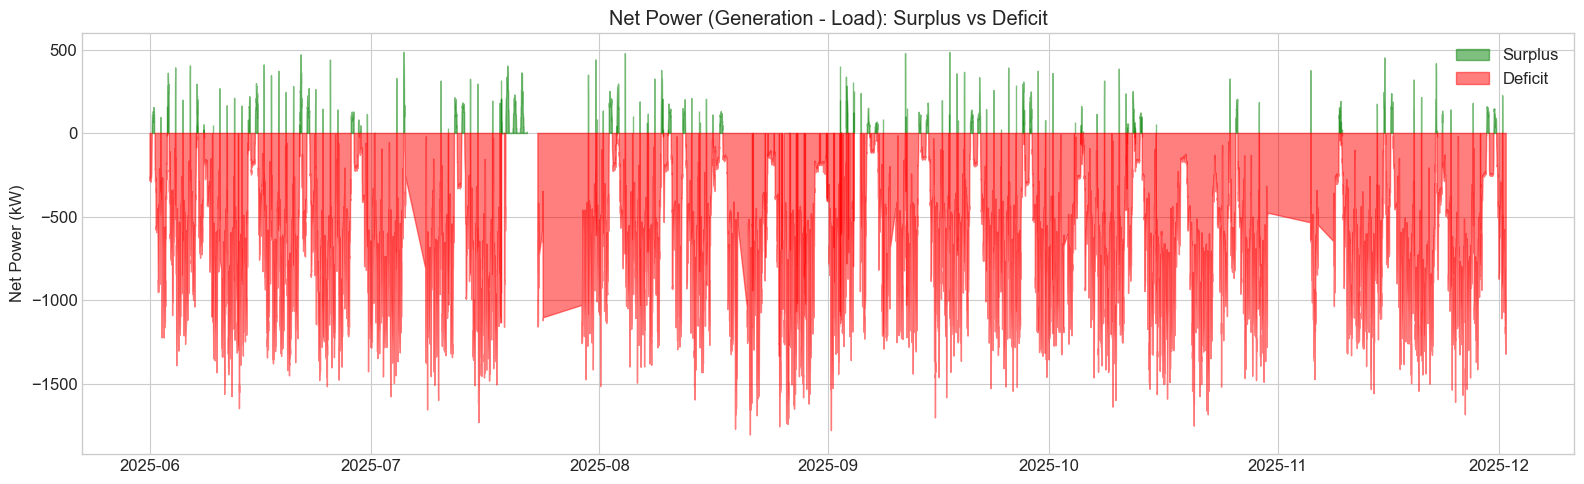

Surplus periods: 10.8%
Deficit periods: 89.2%


In [21]:
df_clean['net_power'] = df_clean['generation_kw'] - df_clean['load_kw']

fig, ax = plt.subplots(figsize=(16, 5))
ax.fill_between(df_clean.index, df_clean['net_power'], 0,
                where=df_clean['net_power'] >= 0, color='green', alpha=0.5, label='Surplus')
ax.fill_between(df_clean.index, df_clean['net_power'], 0,
                where=df_clean['net_power'] < 0, color='red', alpha=0.5, label='Deficit')
ax.set_ylabel('Net Power (kW)')
ax.set_title('Net Power (Generation - Load): Surplus vs Deficit')
ax.legend()
plt.tight_layout()
plt.show()

surplus_pct = (df_clean['net_power'] >= 0).sum() / len(df_clean) * 100
print(f'Surplus periods: {surplus_pct:.1f}%')
print(f'Deficit periods: {100-surplus_pct:.1f}%')

## 13. Save Cleaned Data for Modeling

In [22]:
# Drop helper columns before saving
df_save = df_clean.drop(columns=['hour', 'month', 'dayofweek', 'net_power'], errors='ignore')
df_save.to_csv('datasets/site_1_cleaned.csv')
print(f'Saved cleaned data: {df_save.shape}')
print(f'Columns: {list(df_save.columns)}')
df_save.head()

Saved cleaned data: (15013, 4)
Columns: ['generation_kw', 'irradiance_wm2', 'temperature_c', 'load_kw']


,generation_kw,irradiance_wm2,temperature_c,load_kw
datetime,,,,
2025-06-01 01:00:00,0.0,0.0,24.8,274.0
2025-06-01 01:15:00,0.0,0.0,24.8,273.0
2025-06-01 01:30:00,0.0,0.0,24.8,284.0
2025-06-01 01:45:00,0.0,0.0,24.8,261.0
2025-06-01 02:00:00,0.0,0.0,24.8,270.0


## Summary of EDA Findings

### Data Characteristics
- **Time resolution:** Gen/Irradiance/Temp at ~1-min, Load at 15-min. Resampled all to 15-min.
- **Missing values:** Handled via forward-fill + interpolation (up to 1-hour gaps)

### Key Insights
1. **Generation strongly correlates with Irradiance** - this is the primary driver
2. **Temperature has moderate correlation** with generation
3. **Load follows independent patterns** (consumption is not directly solar-dependent)
4. **Clear daily pattern:** Generation peaks at midday, load has its own consumption pattern
5. **Potential anomalies detected:** High irradiance with low generation indicates equipment issues

### Recommended Approach for Anomaly Detection
- **Target:** Predict `generation_kw` from `irradiance_wm2`, `temperature_c` (and optionally `load_kw`)
- **Anomaly = large prediction error** (when actual generation deviates significantly from what the model predicts given the weather conditions)
- **Methods to use:**
  - ML: Isolation Forest, Random Forest regression
  - DL: LSTM, CNN-LSTM, LSTM Autoencoder, Transformer